In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [7]:
df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Not Available')
df['cast'] = df['cast'].fillna('Not Available')

In [9]:
df['rating'] = df['rating'].fillna('Not Rated')
df['duration'] = df['duration'].fillna('Unknown')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)


In [12]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [13]:
df['date_added'].isnull().sum()

np.int64(10)

In [14]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

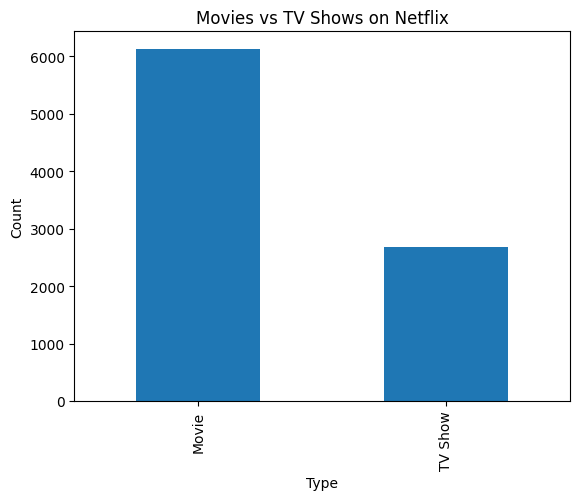

In [15]:
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [16]:
countries = df['country'].str.split(', ', expand=False)

In [17]:
all_countries = []
for i in countries:
    all_countries.extend(i)

In [18]:
country_counts = pd.Series(all_countries).value_counts()
country_counts

United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
                  ... 
Sudan                1
Panama               1
Uganda               1
East Germany         1
Montenegro           1
Name: count, Length: 128, dtype: int64

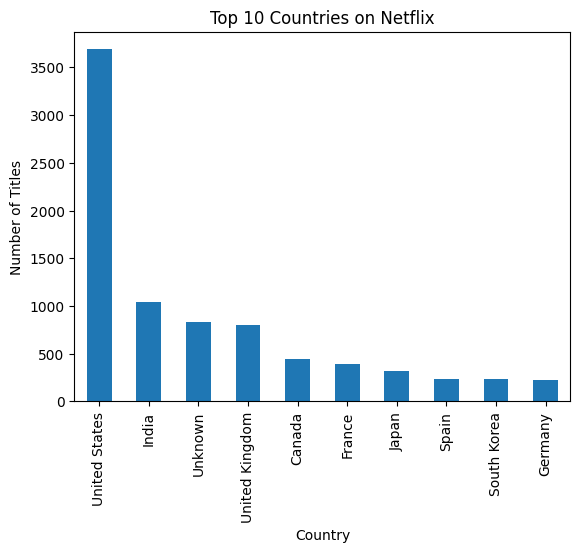

In [19]:

country_counts.head(10).plot(kind='bar')
plt.title("Top 10 Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

In [20]:
df['year_added'] = df['date_added'].dt.year

In [21]:
year_counts = df['year_added'].value_counts().sort_index()
year_counts

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

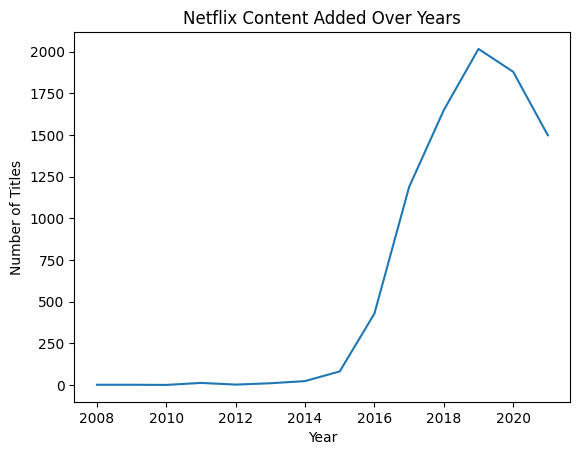

In [22]:
year_counts.plot(kind='line')
plt.title("Netflix Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

In [23]:
df['rating'].value_counts()

rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
74 min          1
84 min          1
66 min          1
Name: count, dtype: int64

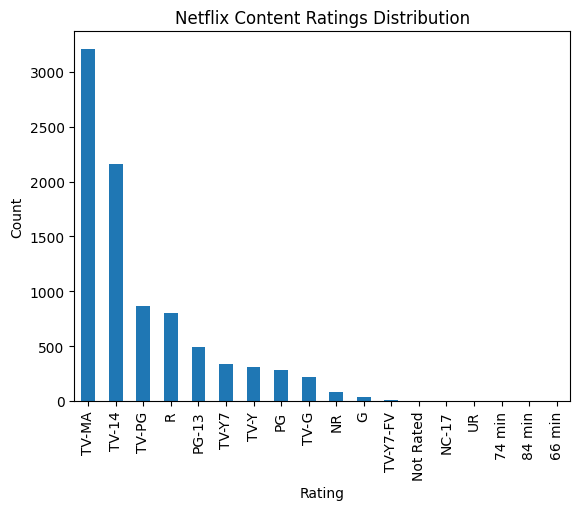

In [24]:
df['rating'].value_counts().plot(kind='bar')
plt.title("Netflix Content Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [25]:

df['listed_in'] = df['listed_in'].fillna('Unknown')
genres = df['listed_in'].str.split(', ', expand=False)

In [26]:
all_genres = []
for i in genres:
    all_genres.extend(i)

In [27]:

genre_counts = pd.Series(all_genres).value_counts()
genre_counts

International Movies            2752
Dramas                          2427
Comedies                        1674
International TV Shows          1351
Documentaries                    869
Action & Adventure               859
TV Dramas                        763
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
TV Comedies                      581
Thrillers                        577
Crime TV Shows                   470
Kids' TV                         451
Docuseries                       395
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 253
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     176
Spanish-Language TV Shows        174
TV Action & Adventure            168
Korean TV Shows                  151
C

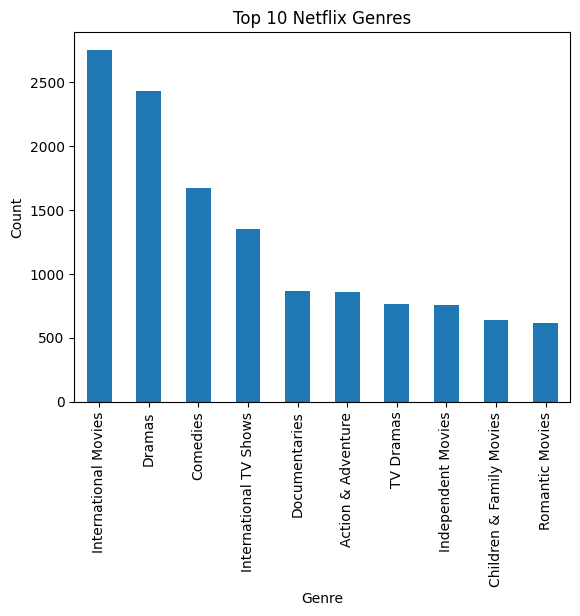

In [28]:
genre_counts.head(10).plot(kind='bar')
plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

In [33]:
trend = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
trend

type,Movie,TV Show
year_added,,
2008.0,1,1
2009.0,2,0
2010.0,1,0
2011.0,13,0
2012.0,3,0
2013.0,6,5
2014.0,19,5
2015.0,56,26
2016.0,253,176


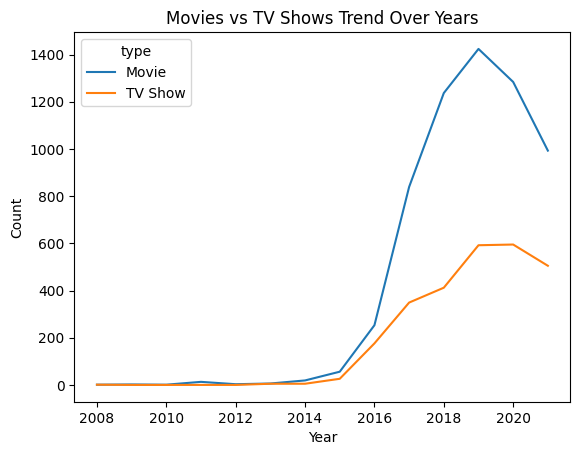

In [34]:
trend.plot(kind='line')
plt.title("Movies vs TV Shows Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [35]:
directors = df['director'].str.split(', ', expand=False)

In [38]:
all_directors = []
for i in directors:
    all_directors.extend(i)


In [39]:
director_counts = pd.Series(all_directors).value_counts()
director_counts.head(10)

Not Available          2634
Rajiv Chilaka            22
Jan Suter                21
Raúl Campos              19
Suhas Kadav              16
Marcus Raboy             16
Jay Karas                15
Cathy Garcia-Molina      13
Youssef Chahine          12
Martin Scorsese          12
Name: count, dtype: int64

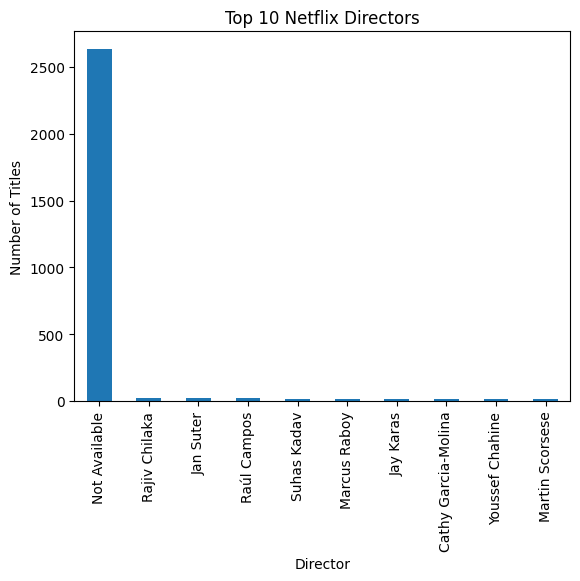

In [40]:
director_counts.head(10).plot(kind='bar')
plt.title("Top 10 Netflix Directors")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.show()

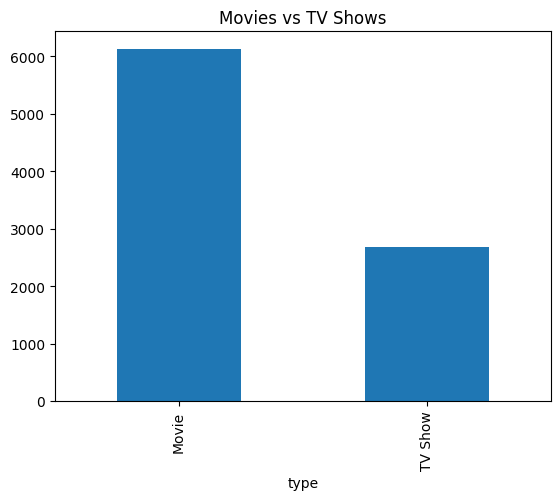

In [44]:
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")

plt.savefig("images/movies_vs_tv.png")
plt.show()

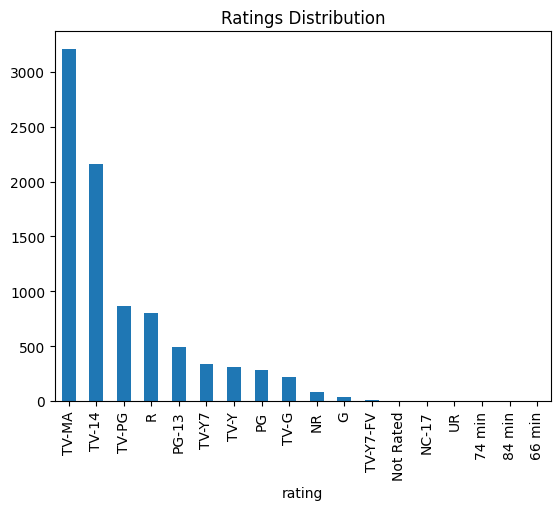

In [45]:
df['rating'].value_counts().plot(kind='bar')
plt.title("Ratings Distribution")

plt.savefig("images/ratings.png")
plt.show()

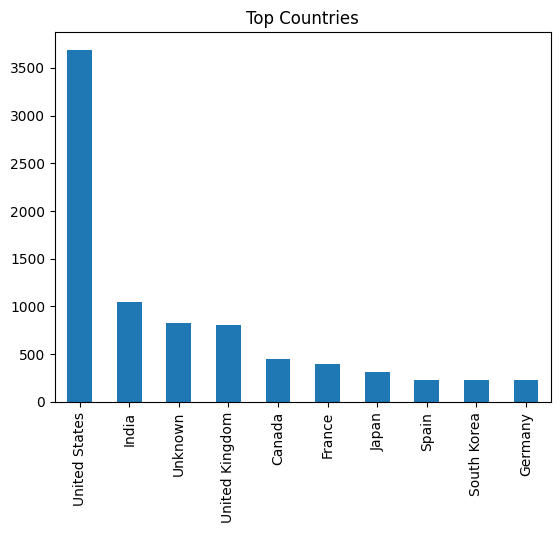

In [46]:
country_counts.head(10).plot(kind='bar')
plt.title("Top Countries")

plt.savefig("images/countries.png")
plt.show()

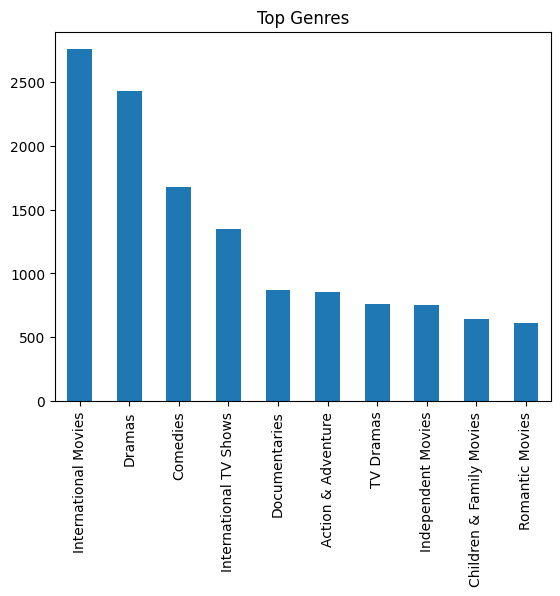

In [47]:
genre_counts.head(10).plot(kind='bar')
plt.title("Top Genres")

plt.savefig("images/genres.png")
plt.show()

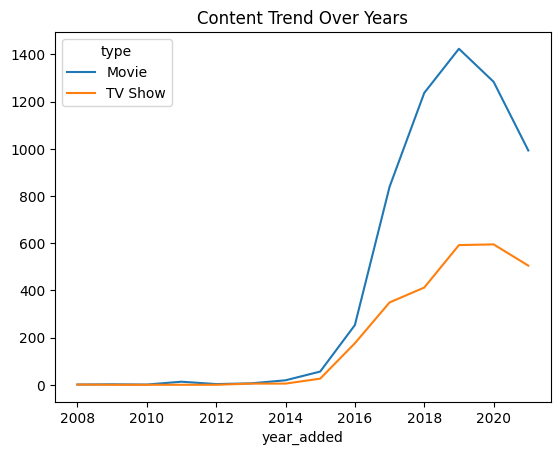

In [48]:
trend.plot(kind='line')
plt.title("Content Trend Over Years")

plt.savefig("images/trend.png")
plt.show()